In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
import umap

%matplotlib widget

In [2]:
data = pd.read_pickle('../activdata/srg/tes/raw/FN/itr_200.bz2')
u = umap.UMAP()

1. Fit the scaler as well as the reducer (u) (commented lines below) to a 'nice' timeseries with clear two different states.
2. Then comment out the fit lines, and use the fitting parameters to simply transform all new data (runs).
3. You should see the time segments getting nicely clustered into two states.
4. The time scale can be controlled using the chunk_size parameter. Smaller parameter value will detect states that last for shorter times. Larger values will require longer persistence within a state to be detected as distinct.

/home/jupyter-saurabh/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


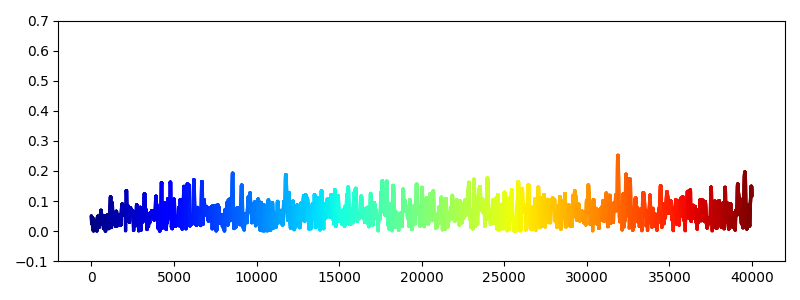

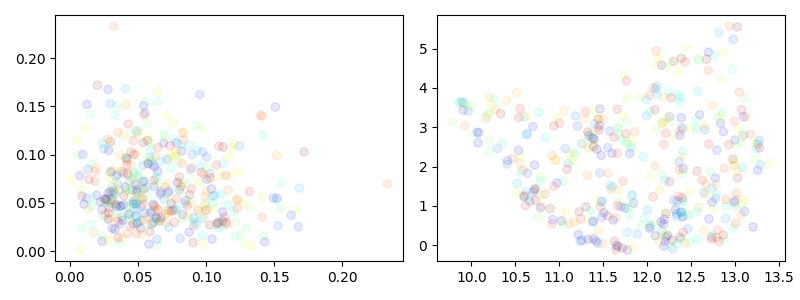

In [30]:
_data = data[59]
cmap = 'jet' # prism or jet

f, ax = plt.subplots(figsize=(8, 3), tight_layout=True)
ax.scatter(_data.index, _data, c=_data.index, s=2, cmap=cmap)
ax.set_ylim(-0.1, 0.7)

f, [ax, ax2] = plt.subplots(1, 2, figsize=(8, 3), tight_layout=True)
ax.scatter(_data[::100], _data.shift(100)[::100], alpha=0.1, c=_data[::100].index, cmap=cmap)

chunk_size = 100
chunks = [_data[i:i + chunk_size] for i in range(0, len(_data), chunk_size)]

# _s = StandardScaler().fit(chunks)
scaled_data = _s.transform(chunks)

# _u = u.fit(scaled_data)
embedding = _u.transform(scaled_data)

ax2.scatter(embedding[:, 0], embedding[:, 1], c=range(len(chunks)), alpha=0.1, cmap=cmap);